<a href="https://colab.research.google.com/github/Wilmot2025/FOOD-APP/blob/main/Binary_logistic_Regression_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset
data = {
    "Student_data": [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "Previous_data": [40, 45, 50, 55, 60, 65, 70, 75],
    "Results": [0, 0, 0, 0, 1, 1, 1, 1]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display dataset
print("Dataset:")
print(df)

# Features
X = df[["Student_data", "Attendance", "Previous_data"]]

# Target
y = df["Results"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# New student data as a list
new_student_list = [[10, 88, 72]]

# Convert new_student_list to a DataFrame with appropriate column names
new_student_df = pd.DataFrame(new_student_list, columns=X.columns)

# Predict using the DataFrame
prediction = model.predict(new_student_df)
probability = model.predict_proba(new_student_df)

print("\nNew Student Prediction:")

if prediction[0] == 1:
    print("The student is predicted to PASS.")
else:
    print("The student is predicted to FAIL.")

print("Probability of Fail:", probability[0][0])
print("Probability of Pass:", probability[0][1])

Dataset:
   Student_data  Attendance  Previous_data  Results
0             2          60             40        0
1             3          65             45        0
2             4          70             50        0
3             5          75             55        0
4             6          80             60        1
5             7          85             65        1
6             8          90             70        1
7             9          95             75        1

Accuracy:
1.0

Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


New Student Prediction:
The student is predicted to PASS.
Probability of Fail: 7.704221771764885e-06
Probability of Pass: 

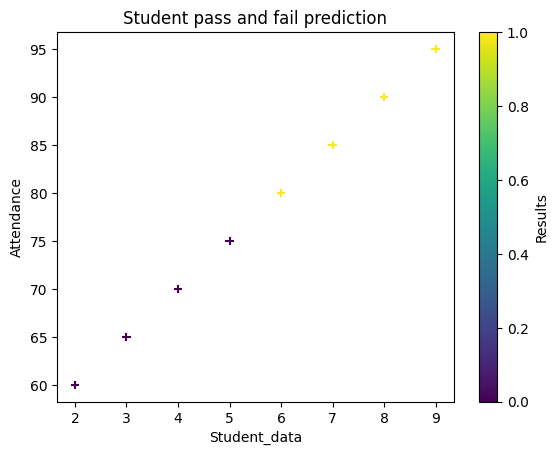

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df.Student_data, df.Attendance, c=df.Results, cmap='viridis', marker='+')
plt.xlabel('Student_data')
plt.ylabel('Attendance')
plt.title('Student pass and fail prediction')
plt.colorbar(label='Results')


plt.show()

In [15]:
# Calculate predicted probabilities for the training set
train_probabilities = model.predict_proba(X_train)

print("Predicted Probabilities for Training Set (Fail, Pass):")
# Display the probabilities, linking them back to the original training data if possible
for i, (idx, row) in enumerate(X_train.iterrows()):
    print(f"  Student_data: {row['Student_data']}, Attendance: {row['Attendance']}, Previous_data: {row['Previous_data']}: Probabilities = {train_probabilities[i]}")


Predicted Probabilities for Training Set (Fail, Pass):
  Student_data: 2, Attendance: 60, Previous_data: 40: Probabilities = [9.99999912e-01 8.83199615e-08]
  Student_data: 9, Attendance: 95, Previous_data: 75: Probabilities = [8.93387115e-08 9.99999911e-01]
  Student_data: 4, Attendance: 70, Previous_data: 50: Probabilities = [9.99055832e-01 9.44167527e-04]
  Student_data: 6, Attendance: 80, Previous_data: 60: Probabilities = [0.08998853 0.91001147]
  Student_data: 5, Attendance: 75, Previous_data: 55: Probabilities = [0.91094624 0.08905376]
  Student_data: 8, Attendance: 90, Previous_data: 70: Probabilities = [9.24136036e-06 9.99990759e-01]


In [14]:
# Display the coefficients of the model
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

# Display the intercept of the model
print(f"\nModel Intercept: {model.intercept_[0]:.4f}")

Model Coefficients:
  Student_data: 0.0910
  Attendance: 0.4548
  Previous_data: 0.4548

Model Intercept: -61.9048


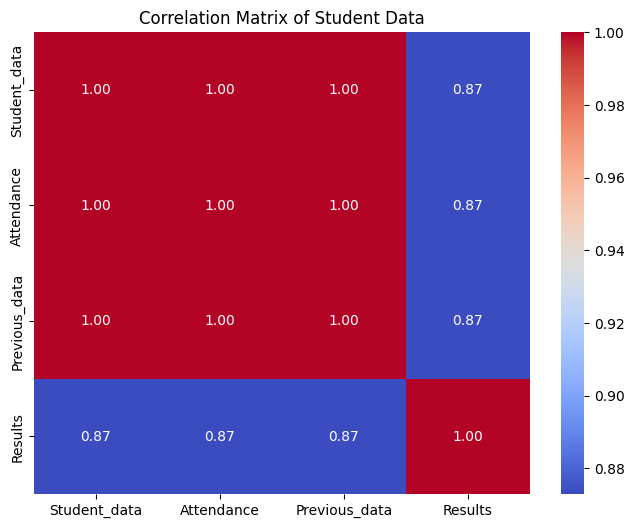

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Student Data')
plt.show()